In [67]:
from carpenter import emission
from carpenter import conventions
from carpenter import pixels
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.visualization import make_lupton_rgb

In [ ]:
# Path where cutouts are saved
image_path = 'example_images'

# ID of merian object
merian_id = 3503272744512935695
redshift = 0.076

# coordinates of Merian object
ra, dec = 177.17704805263534, 2.5105410847720755

# Make merian object name from coordinates
objectname = conventions.produce_merianobjectname(ra, dec)

In [24]:
# Create empty broadband-mediumband object and load images and psfs
bbmb = pixels.BBMBImage()

[bbmb.add_band(b, 
            [ra, dec], 
            100, 
            image = f'{image_path}/hsc/{objectname}_HSC-{b}.fits',
            var = f'{image_path}/hsc/{objectname}_HSC-{b}.fits',
            psf = f'{image_path}/hsc/{objectname}_HSC-{b}_psf.fits',
            image_ext = 1,
            var_ext = 3) for b in 'griz']

[bbmb.add_band(b, 
            [ra, dec], 
            100, 
            image = f'{image_path}/merian/{objectname}_{b}_merim.fits',
            var = f'{image_path}/merian/{objectname}_{b}_merim.fits',
            psf = f'{image_path}/merian/{objectname}_{b}_merpsf.fits',
            image_ext = 1,
            var_ext = 3) for b in ['N540', 'N708']]

[None, None]

In [72]:
# Measure PSF sizes and find band with largest PSF
fwhm_a, model_psf = bbmb.measure_psfsizes(save=True)
match_psf_band = ['g', 'r', 'i', 'z', 'N540', 'N708'][fwhm_a[np.isin(bbmb.bands, ['g', 'r', 'i', 'z', 'N540', 'N708'])].argmax()]

# reproject all the images to a common WCS and pixel grid
bbmb.reproject(refband = match_psf_band, psf_matched = False)

# Match PSFs to the largest PSF band, using the model PSF for convolution kernels
# Note you can choose different convolution kernels if you want
_ = bbmb.match_psfs(refband = match_psf_band, verbose=False, w_type='hanning', reprojected=True, use_model_psf=True) 

# Compute the medium band excess HA image
# Note the ha variance map is just the medium band variance map for now...
# You can also choose different methods for the continuum estimation
ha_im, ha_var, ha_continuum = bbmb.compute_mbexcess(band = 'N708',
                                method = '2dpowerlaw',
                                redshift = redshift)

# And O[III], but this is less well tested
oiii_im, oiii_var, oiii_continuum = bbmb.compute_mbexcess(band = 'N540',
                                method = '2dpowerlaw',
                                redshift = redshift)

# Make a figure!

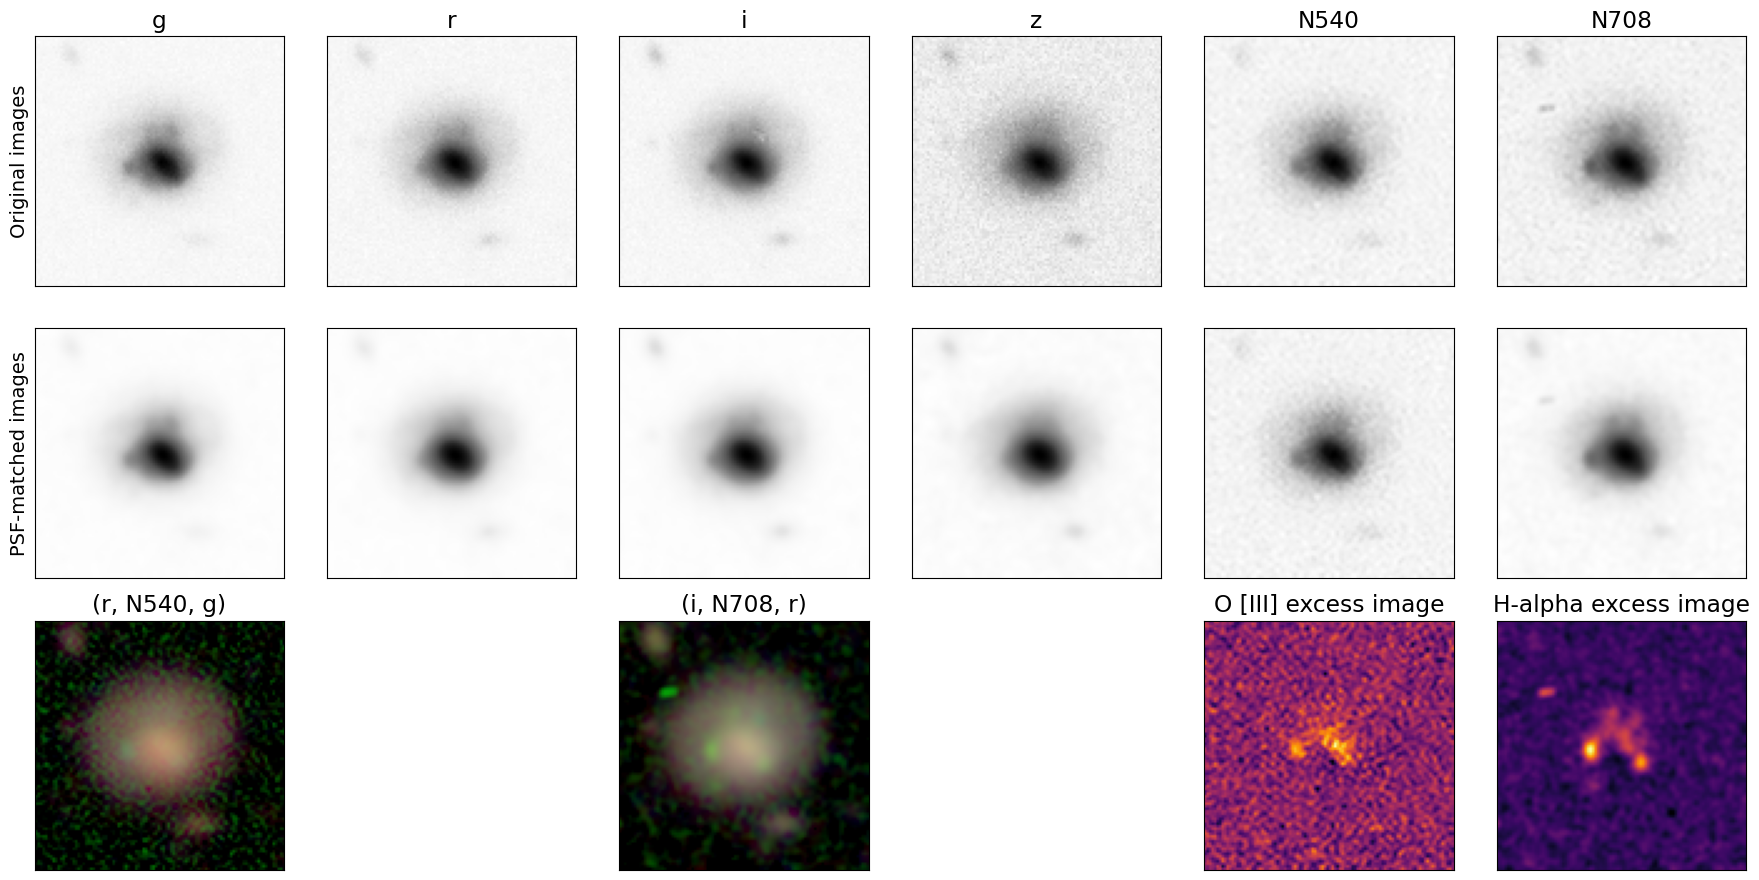

In [73]:
fig, ax = plt.subplots(3, 6, figsize=(18,9))
[a.imshow(bbmb.image[b], norm = colors.AsinhNorm(), cmap = 'Greys') for b, a in zip(bbmb.bands, ax[0])]
[a.imshow(bbmb.matched_image[b], norm = colors.AsinhNorm(), cmap = 'Greys') for b, a in zip(bbmb.bands, ax[1])]
[a.set_title(b) for b, a in zip(bbmb.bands, ax[0])]
[(a.set_xticks([]), a.set_yticks([])) for a in ax.flatten()]
ax[0,0].set_ylabel('Original images')
ax[1,0].set_ylabel('PSF-matched images')

ax[2, 0].imshow(make_lupton_rgb(bbmb.matched_image['r'], bbmb.matched_image['N540'], bbmb.matched_image['g'], stretch=0.5, Q=10))
ax[2, 0].set_title('(r, N540, g)')
ax[2, 2].imshow(make_lupton_rgb(bbmb.matched_image['i'], bbmb.matched_image['N708'], bbmb.matched_image['r'], stretch=0.5, Q=10))
ax[2, 2].set_title('(i, N708, r)')

ax[2, 4].imshow(oiii_im, norm = colors.AsinhNorm(), cmap = 'inferno')
ax[2, 4].set_title('O [III] excess image')

ax[2, 5].imshow(ha_im, norm = colors.AsinhNorm(), cmap = 'inferno')
ax[2, 5].set_title('H-alpha excess image')

[a.set_axis_off() for a in ax[2, [1,3]]]
plt.tight_layout()